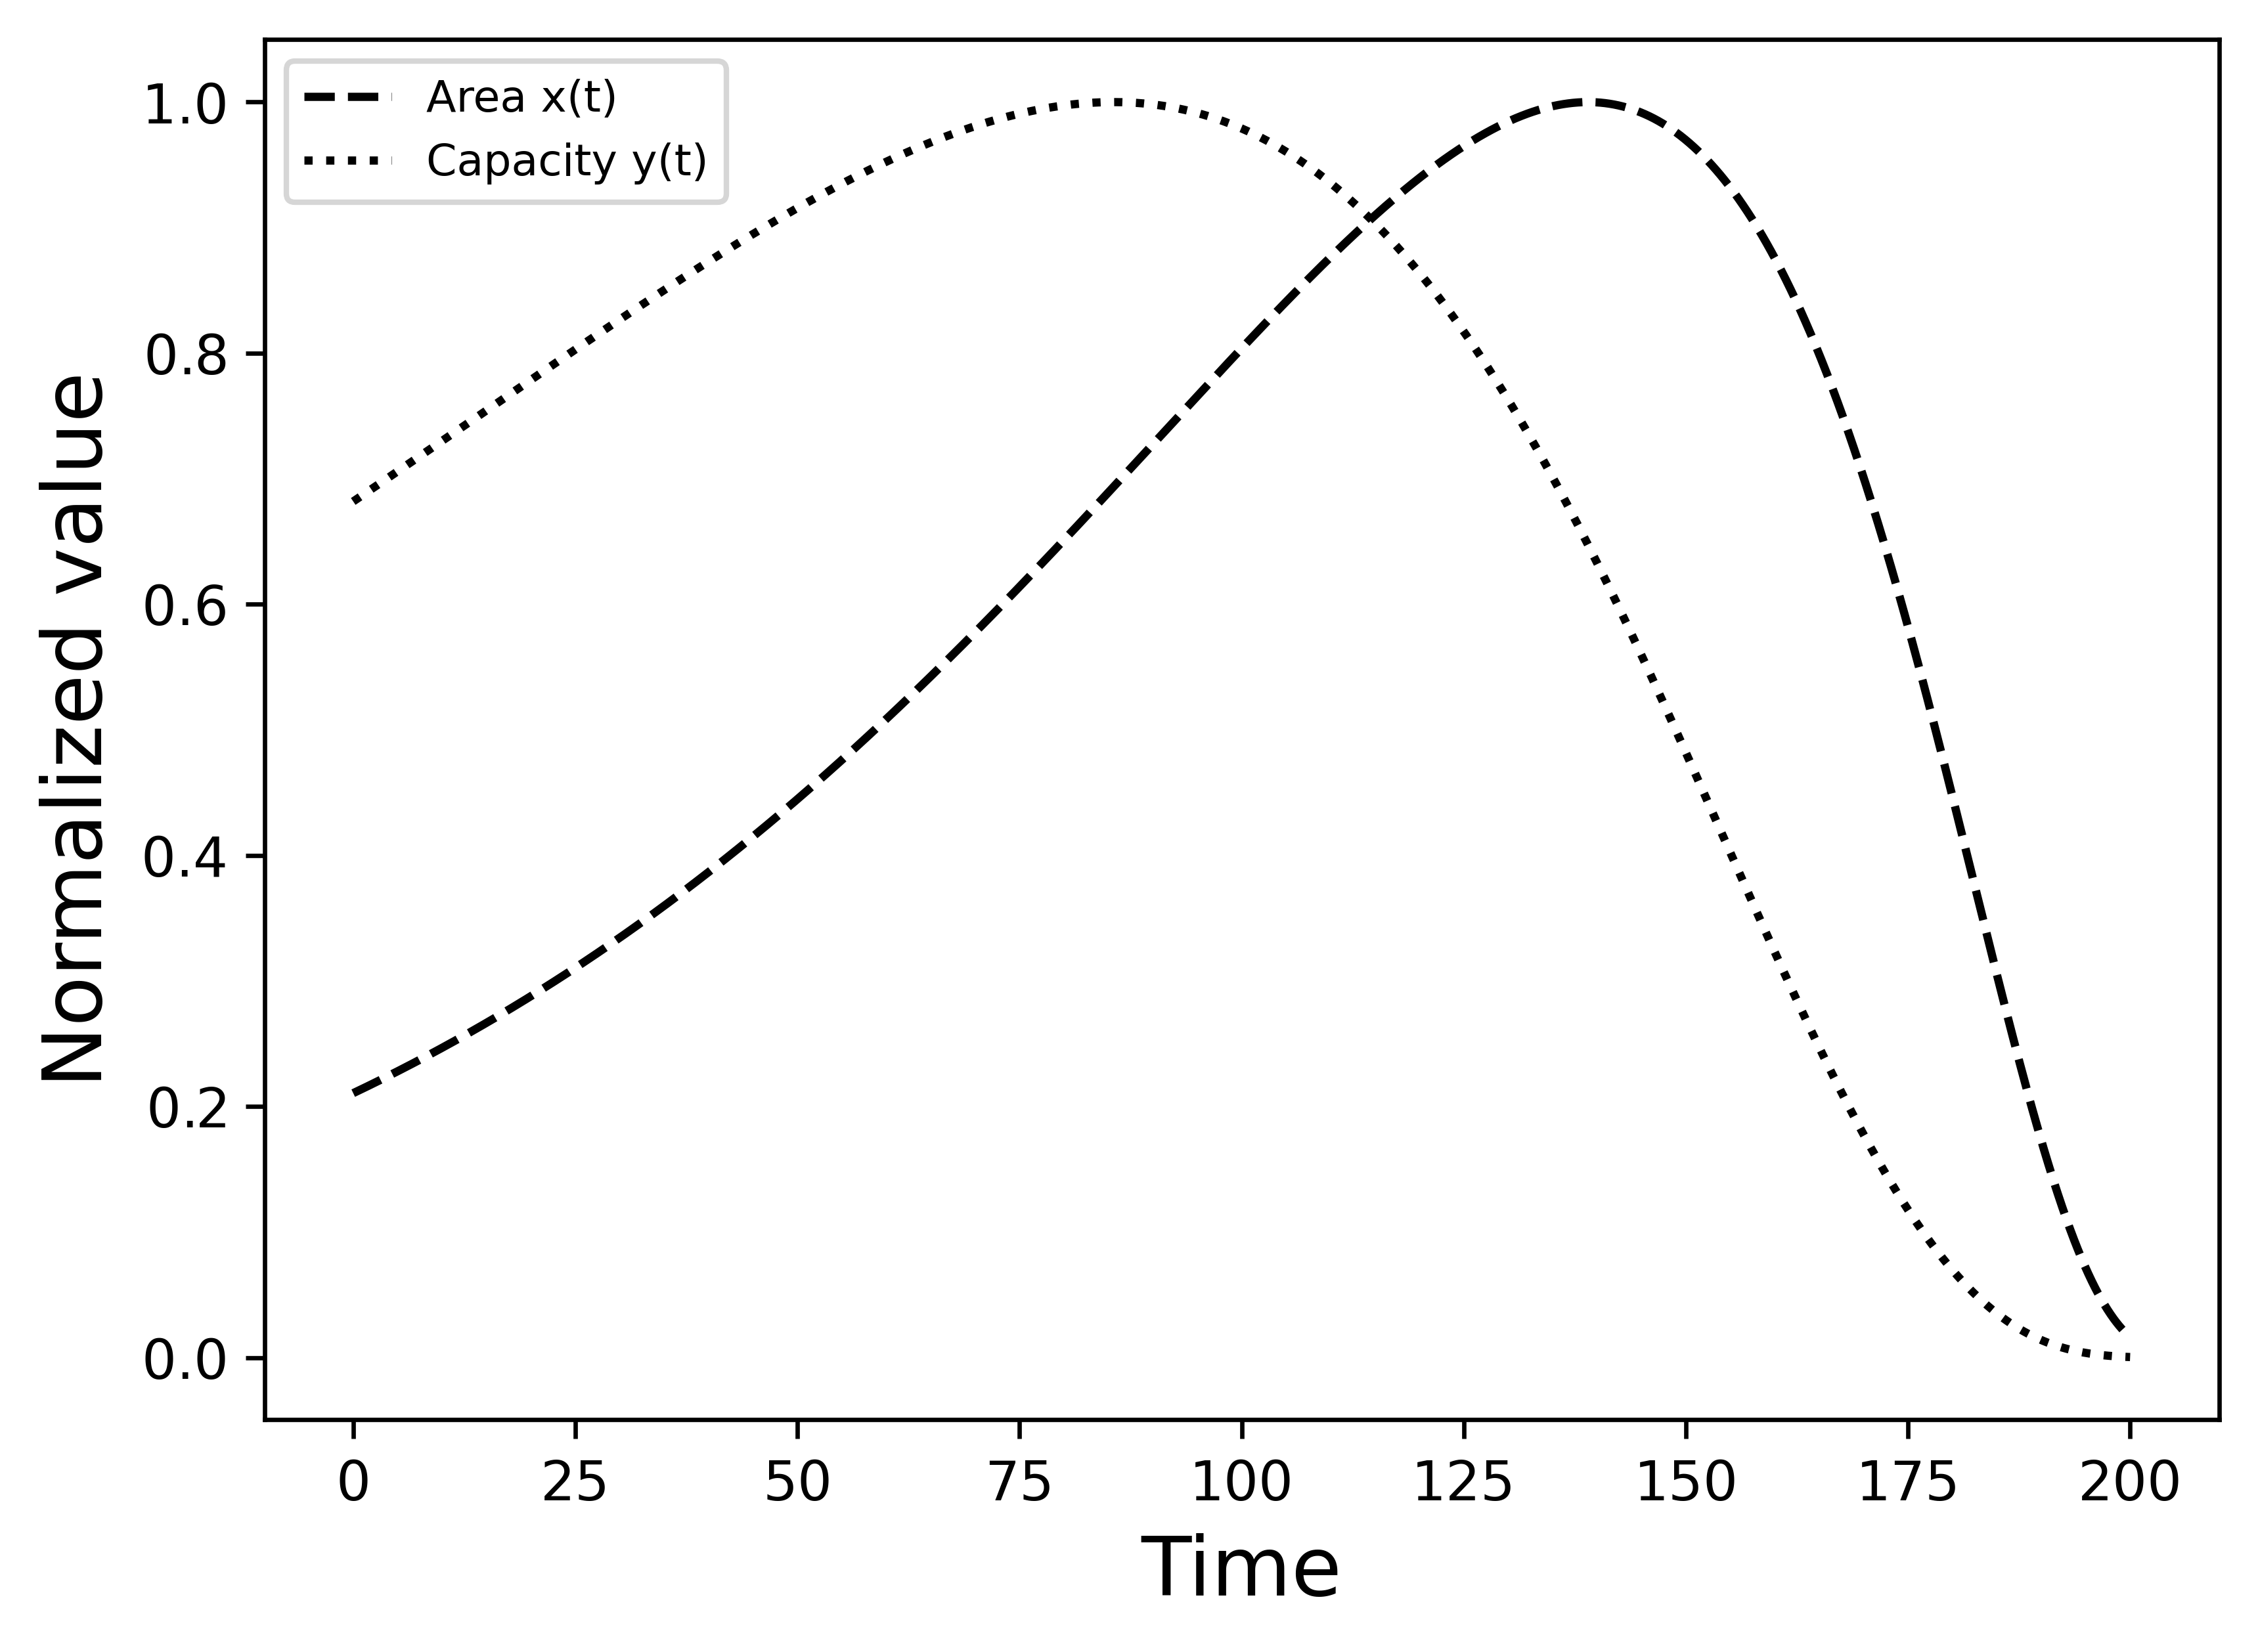

Saved figures + parameters to: optimal_control
Main figure displayed and saved as transient.pdf


In [6]:
# =============================================================================
# Title: Optimal-control formulation and simulation of imperial dynamics
#
# Description:
# This script implements and simulates the full current-value Hamiltonian system
# underlying the dynamical model of imperial expansion and decline.
#
# The framework provides an optimal-control representation of territorial
# expansion, where growth is balanced against the costs of maintaining and
# integrating an expanding domain.
#
# Model structure:
# - State variables:
#       x(t) : territorial extent (area)
#       y(t) : effective capacity or integration constraint
#
# - Costate variables:
#       mu_x(t), mu_y(t)
#
# - Control:
#       v(t) : expansion rate, determined endogenously from the Hamiltonian
#
# The system couples logistic-type growth of x with a dynamically evolving
# capacity y, whose evolution reflects the trade-off between expansion benefits
# and the costs of coordination and maintenance.
#
# General system:
#       xdot = r x (1 - x/y)
#       ydot = v y
#
#       v* = (r - gamma)(1 - x/y) - alpha + (mu_y y)/kappa
#
#       mu_x_dot = (rho-r) mu_x + 2r(x/y)mu_x - 2C(x/y)
#                  + kappa((r-gamma)/y)v
#
#       mu_y_dot = (rho-v) mu_y + C x^2/y^2
#                  - kappa(r-gamma) x v / y^2
#                  - r mu_x x^2 / y^2
#
# Numerical method:
# - Fourth-order Runge–Kutta (RK4) integration of the coupled state-costate system
#
# Output:
# - Time series for x, y, mu_x, mu_y
# - Derived quantities (control v, ratio x/y)
# - Main figure: normalized x(t) and y(t) on the same axes
# - Additional diagnostic plots and saved data (CSV and JSON)
#
# Interpretation:
# The dynamics capture the endogenous emergence of limits to expansion through
# increasing internal constraints, providing a mechanistic counterpart to the
# reduced-form Gompertz trajectory used in the empirical analysis.
#
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import os, json

def v_star(x, y, mu_y, gamma, r, alpha, kappa):
    y = max(y, 1e-12)
    return (r - gamma) * (1.0 - x / y) - alpha + (mu_y * y) / kappa

def rhs(t, S, rho, gamma, r, alpha, C, kappa):
    x, y, mu_x, mu_y = S
    y = max(y, 1e-12)

    v = v_star(x, y, mu_y, gamma, r, alpha, kappa)

    # State dynamics
    xdot = r * x * (1.0 - x / y)
    ydot = v * y

    # Costate dynamics
    mux_dot = (
        (rho - r) * mu_x
        + 2.0 * r * (x / y) * mu_x
        - 2.0 * C * (x / y)
        + kappa * ((r - gamma) / y) * v
    )

    muy_dot = (
        (rho - v) * mu_y
        + C * x**2 / y**2
        - kappa * (r - gamma) * x * v / y**2
        - r * mu_x * x**2 / y**2
    )

    return np.array([xdot, ydot, mux_dot, muy_dot], dtype=float)

def rk4(sim_rhs, t0, t1, dt, S0, args):
    n = int(np.floor((t1 - t0) / dt)) + 1
    t = t0 + dt * np.arange(n)
    X = np.zeros((n, len(S0)), dtype=float)
    X[0] = np.array(S0, dtype=float)

    for i in range(n - 1):
        ti = t[i]
        Si = X[i]

        k1 = sim_rhs(ti,          Si,             *args)
        k2 = sim_rhs(ti + dt/2.0, Si + dt*k1/2.0, *args)
        k3 = sim_rhs(ti + dt/2.0, Si + dt*k2/2.0, *args)
        k4 = sim_rhs(ti + dt,     Si + dt*k3,     *args)

        X[i + 1] = Si + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    return t, X

def savefig(path, dpi=600, show=False):
    plt.savefig(path, bbox_inches='tight', pad_inches=0, dpi=dpi)
    if show:
        plt.show()
    plt.close()

def plot_solution(t, X, rho, gamma, r, alpha, C, kappa, outdir, dpi=600):
    x, y, mu_x, mu_y = X[:, 0], X[:, 1], X[:, 2], X[:, 3]
    y_safe = np.maximum(y, 1e-12)

    # Normalize x and y only for plotting
    x_plot = x / np.max(x) if np.max(x) != 0 else x.copy()
    y_plot = y / np.max(y) if np.max(y) != 0 else y.copy()

    v = np.array([v_star(xi, yi, muyi, gamma, r, alpha, kappa)
                  for xi, yi, muyi in zip(x, y_safe, mu_y)])
    z = x / y_safe

    # Main figure: normalized x and y together
    plt.figure(dpi=dpi)
    plt.gca().yaxis.set_major_formatter(mtick.ScalarFormatter(useMathText=True))

    plt.plot(t, x_plot, linestyle='--', c='k', label='Area x(t)')
    plt.plot(t, y_plot, linestyle=':',  c='k', label='Capacity y(t)')

    plt.ylabel('Normalized value', fontsize=15)
    plt.xlabel('Time', fontsize=15)
    plt.tick_params(axis='both', which='major', labelsize=10)
    plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 5))
    plt.gcf().subplots_adjust(bottom=0.15)
    plt.legend(loc="upper left", fontsize=8, frameon=True)

    savefig(os.path.join(outdir, "transient.pdf"), dpi=dpi, show=True)

    # Other saved figures
    plt.figure(dpi=dpi)
    plt.plot(t, x_plot)
    plt.xlabel("Time", fontsize=15)
    plt.ylabel("Normalized x", fontsize=15)
    plt.tick_params(axis='both', which='major', labelsize=10)
    plt.gcf().subplots_adjust(bottom=0.15)
    savefig(os.path.join(outdir, "x_t.png"), dpi=dpi)

    plt.figure(dpi=dpi)
    plt.plot(t, y_plot)
    plt.xlabel("Time", fontsize=15)
    plt.ylabel("Normalized y", fontsize=15)
    plt.tick_params(axis='both', which='major', labelsize=10)
    plt.gcf().subplots_adjust(bottom=0.15)
    savefig(os.path.join(outdir, "y_t.png"), dpi=dpi)

    plt.figure(dpi=dpi)
    plt.plot(t, mu_x)
    plt.xlabel("Time", fontsize=15)
    plt.ylabel(r'$\mu_x$', fontsize=15)
    plt.tick_params(axis='both', which='major', labelsize=10)
    plt.gcf().subplots_adjust(bottom=0.15)
    savefig(os.path.join(outdir, "mu_x_t.png"), dpi=dpi)

    plt.figure(dpi=dpi)
    plt.plot(t, mu_y)
    plt.xlabel("Time", fontsize=15)
    plt.ylabel(r'$\mu_y$', fontsize=15)
    plt.tick_params(axis='both', which='major', labelsize=10)
    plt.gcf().subplots_adjust(bottom=0.15)
    savefig(os.path.join(outdir, "mu_y_t.png"), dpi=dpi)

    plt.figure(dpi=dpi)
    plt.plot(t, v)
    plt.xlabel("Time", fontsize=15)
    plt.ylabel("v", fontsize=15)
    plt.tick_params(axis='both', which='major', labelsize=10)
    plt.gcf().subplots_adjust(bottom=0.15)
    savefig(os.path.join(outdir, "v_t.png"), dpi=dpi)

    plt.figure(dpi=dpi)
    plt.plot(t, z)
    plt.xlabel("Time", fontsize=15)
    plt.ylabel("x/y", fontsize=15)
    plt.tick_params(axis='both', which='major', labelsize=10)
    plt.gcf().subplots_adjust(bottom=0.15)
    savefig(os.path.join(outdir, "x_over_y_t.png"), dpi=dpi)

if __name__ == "__main__":
    # Parameters
    r = 0.02
    gamma = 0.01
    rho = 0.02
    alpha = 0.001
    C = 0.1
    kappa = 10e5

    # Initial conditions
    x0 = 0.2
    y0 = 1.0
    mux0 = 1.0
    muy0 = 0.0

    # Time grid
    t0 = 0.0
    t1 = 200.0
    dt = 0.05

    outdir = "optimal_control"
    os.makedirs(outdir, exist_ok=True)

    params = {
        "rho": rho,
        "gamma": gamma,
        "r": r,
        "alpha": alpha,
        "C": C,
        "kappa": kappa,
        "x0": x0,
        "y0": y0,
        "mux0": mux0,
        "muy0": muy0,
        "t0": t0,
        "t1": t1,
        "dt": dt
    }

    with open(os.path.join(outdir, "parameters.json"), "w") as f:
        json.dump(params, f, indent=4)

    t, X = rk4(
        rhs,
        t0,
        t1,
        dt,
        [x0, y0, mux0, muy0],
        args=(rho, gamma, r, alpha, C, kappa)
    )

    np.savetxt(
        os.path.join(outdir, "trajectory.csv"),
        np.column_stack([t, X]),
        delimiter=",",
        header="t,x,y,mu_x,mu_y",
        comments=""
    )

    plot_solution(t, X, rho, gamma, r, alpha, C, kappa, outdir)

    print(f"Saved figures + parameters to: {outdir}")
    print("Main figure displayed and saved as transient.pdf")